In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:

df = pd.read_csv("content/lichess_db_puzzle.csv.zst")

In [60]:
df.shape

(5311149, 10)

In [40]:
df.head(10)

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN
1,0000D,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1492,74,96,33381,advantage endgame short,https://lichess.org/F8M8OS71#53,NaN
2,0008Q,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1340,77,91,726,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN
3,0009B,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1103,74,88,598,advantage middlegame short,https://lichess.org/4MWQCxQ6/black#32,Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Vari...
4,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,77,100,168,crushing endgame fork short,https://lichess.org/au2lCK5o#73,NaN
5,000VW,r4r2/1p3pkp/p5p1/3R1N1Q/3P4/8/P1q2P2/3R2K1 b -...,g6f5 d5c5 c2e4 h5g5 g7h8 g5f6,2854,107,85,257,crushing endgame long,https://lichess.org/e9AY2m5j/black#50,NaN
6,000Vc,8/8/4k1p1/2KpP2p/5PP1/8/8/8 w - - 0 53,g4h5 g6h5 f4f5 e6e5 f5f6 e5f6,1615,79,75,106,crushing endgame long pawnEndgame,https://lichess.org/l6AejDMO#105,NaN
7,000Zo,4r3/1k6/pp3r2/1b2P2p/3R1p2/P1R2P2/1P4PP/6K1 w ...,e5f6 e8e1 g1f2 e1f1,1353,75,86,631,endgame mate mateIn2 short,https://lichess.org/n8Ff742v#69,NaN
8,000aY,r4rk1/pp3ppp/2n1b3/q1pp2B1/8/P1Q2NP1/1PP1PP1P/...,g5e7 a5c3 b2c3 c6e7,1436,78,75,519,advantage master middlegame short,https://lichess.org/iihZGl6t#29,Benoni_Defense Benoni_Defense_Benoni-Indian_De...
9,000h0,5rk1/p5p1/3bpr1p/1Pp4q/3pR3/1P1Q1N2/P4PPP/4R1K...,e4e6 f6f3 g2f3 h5h2 g1f1 h2h3 f1e2 h3e6,1930,137,100,7,advantage interference kingsideAttack middlega...,https://lichess.org/OWe6M5dF#43,NaN


In [61]:
def levels(x):
  if x < 900:
    return "Easy"
  elif x < 1200:
    return "Medium"
  elif x < 1500:
    return "Hard"
  elif x < 1800:
    return "Master"
  else:
    return "too hard"

In [62]:
df["Difficulty"] = df["Rating"].apply(levels)
df.head(10)


,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,Difficulty
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN,too hard
1,0000D,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1492,74,96,33381,advantage endgame short,https://lichess.org/F8M8OS71#53,NaN,Hard
2,0008Q,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1340,77,91,726,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN,Hard
3,0009B,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1103,74,88,598,advantage middlegame short,https://lichess.org/4MWQCxQ6/black#32,Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Vari...,Medium
4,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,77,100,168,crushing endgame fork short,https://lichess.org/au2lCK5o#73,NaN,Hard
5,000VW,r4r2/1p3pkp/p5p1/3R1N1Q/3P4/8/P1q2P2/3R2K1 b -...,g6f5 d5c5 c2e4 h5g5 g7h8 g5f6,2854,107,85,257,crushing endgame long,https://lichess.org/e9AY2m5j/black#50,NaN,too hard
6,000Vc,8/8/4k1p1/2KpP2p/5PP1/8/8/8 w - - 0 53,g4h5 g6h5 f4f5 e6e5 f5f6 e5f6,1615,79,75,106,crushing endgame long pawnEndgame,https://lichess.org/l6AejDMO#105,NaN,Master
7,000Zo,4r3/1k6/pp3r2/1b2P2p/3R1p2/P1R2P2/1P4PP/6K1 w ...,e5f6 e8e1 g1f2 e1f1,1353,75,86,631,endgame mate mateIn2 short,https://lichess.org/n8Ff742v#69,NaN,Hard
8,000aY,r4rk1/pp3ppp/2n1b3/q1pp2B1/8/P1Q2NP1/1PP1PP1P/...,g5e7 a5c3 b2c3 c6e7,1436,78,75,519,advantage master middlegame short,https://lichess.org/iihZGl6t#29,Benoni_Defense Benoni_Defense_Benoni-Indian_De...,Hard
9,000h0,5rk1/p5p1/3bpr1p/1Pp4q/3pR3/1P1Q1N2/P4PPP/4R1K...,e4e6 f6f3 g2f3 h5h2 g1f1 h2h3 f1e2 h3e6,1930,137,100,7,advantage interference kingsideAttack middlega...,https://lichess.org/OWe6M5dF#43,NaN,too hard


In [63]:

df["Themes"] = df["Themes"].astype(str).fillna("")
themes = [
    "bishopEndgame","knightEndgame","pawnEndgame","queenEndgame","rookEndgame",
    "hangingPiece","fork","discoveredAttack","skewer","sacrifice"
]
for t in themes:
  df[t] = df["Themes"].str.contains(t, case = False, na = False).astype(int)
df = df[df[themes].any(axis=1)].reset_index(drop=True)
df[["PuzzleId", "Themes"] + themes].head()


,PuzzleId,Themes,bishopEndgame,knightEndgame,pawnEndgame,queenEndgame,rookEndgame,hangingPiece,fork,discoveredAttack,skewer,sacrifice
0,00008,crushing hangingPiece long middlegame,0,0,0,0,0,1,0,0,0,0
1,0008Q,advantage endgame rookEndgame short,0,0,0,0,1,0,0,0,0,0
2,000Pw,crushing endgame fork short,0,0,0,0,0,0,1,0,0,0
3,000Vc,crushing endgame long pawnEndgame,0,0,1,0,0,0,0,0,0,0
4,000lC,advantage hangingPiece middlegame short,0,0,0,0,0,1,0,0,0,0


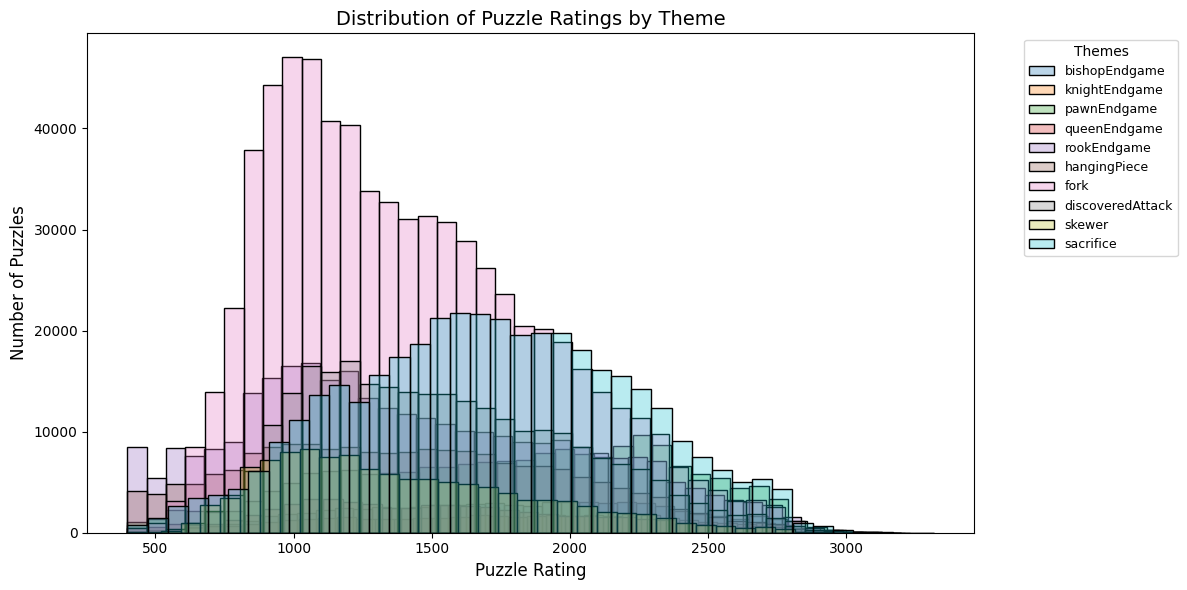

In [64]:
themes_1 = ["bishopEndgame","knightEndgame","pawnEndgame","queenEndgame"]
themes_2 = ["rookEndgame", "hangingPiece","fork"]
themes_3 = ["discoveredAttack","skewer","sacrifice"]
plt.figure(figsize=(12, 6))
colors = sns.color_palette("tab10", 10)
for t, color in zip(themes, colors):
    sns.histplot(df.loc[df[t] == 1, "Rating"],bins=40,label=t,kde=False,alpha=0.3,color=color)

plt.xlabel("Puzzle Rating", fontsize=12)
plt.ylabel("Number of Puzzles", fontsize=12)
plt.title("Distribution of Puzzle Ratings by Theme", fontsize=14)
plt.legend(title="Themes", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


# New Section

In [65]:
def get_num_moves(x):
  return len(x.split(" ")) / 2

In [66]:
df = df.dropna(subset=['Moves'])

<Axes: xlabel='num_moves', ylabel='count'>

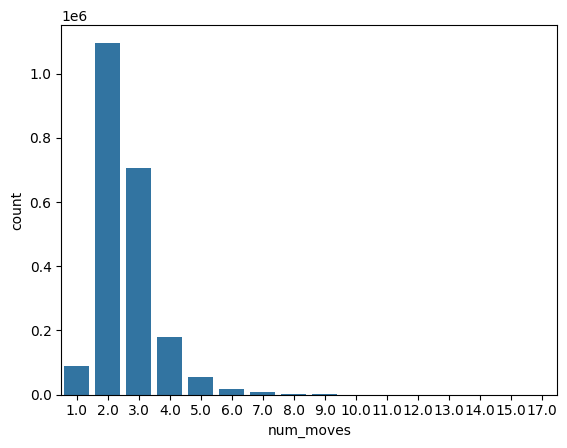

In [67]:
df['num_moves'] = df['Moves'].apply(get_num_moves)
sns.countplot(data=df, x='num_moves')

In [68]:
df.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,...,knightEndgame,pawnEndgame,queenEndgame,rookEndgame,hangingPiece,fork,discoveredAttack,skewer,sacrifice,num_moves
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN,...,0,0,0,0,1,0,0,0,0,3.0
1,0008Q,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1340,77,91,726,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN,...,0,0,0,1,0,0,0,0,0,2.0
2,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,77,100,168,crushing endgame fork short,https://lichess.org/au2lCK5o#73,NaN,...,0,0,0,0,0,1,0,0,0,2.0
3,000Vc,8/8/4k1p1/2KpP2p/5PP1/8/8/8 w - - 0 53,g4h5 g6h5 f4f5 e6e5 f5f6 e5f6,1615,79,75,106,crushing endgame long pawnEndgame,https://lichess.org/l6AejDMO#105,NaN,...,0,1,0,0,0,0,0,0,0,3.0
4,000lC,3r3r/pQNk1ppp/1qnb1n2/1B6/8/8/PPP3PP/3R1R1K w ...,d1d6 d7d6 b7b6 a7b6,1378,76,94,4443,advantage hangingPiece middlegame short,https://lichess.org/vaqz2bx6#37,NaN,...,0,0,0,0,1,0,0,0,0,2.0


In [69]:
def getPuzzle(rating, theme):
  dfTheme = df[df[theme] == 1]
  dfThemeAndRating = dfTheme[(dfTheme["Rating"] <= rating + 300) & (dfTheme["Rating"] >= rating - 300)]
  thingToReturn = dfThemeAndRating.sample()
  return thingToReturn

In [70]:
#Rating

def deltaRating(currentRating, puzzleRating, progress, solved, deltaMax, shapeOfDecay):
  '''
  currentRating = student current rating
  puzzleRating = how hard the puzzle is
  progress = percentage of diagnostic completed
  solved = 0/1 if they solved the puzzle
  deltaMax = max amount of change
  shapeOfDecay = how much the deltaRating changes as the student progresses
  '''
  Kmin = 12
  Kmax = 75 #Learning Rates
  k = Kmin + (Kmax - Kmin) * (1 - progress) ** shapeOfDecay

  expected = 1 / (1 + 10 ** ((puzzleRating - currentRating) / 400))

  delta = k * (solved - expected)
  delta = max(-deltaMax, min(delta, deltaMax))

  return currentRating + delta



df.head()


,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,...,knightEndgame,pawnEndgame,queenEndgame,rookEndgame,hangingPiece,fork,discoveredAttack,skewer,sacrifice,num_moves
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN,...,0,0,0,0,1,0,0,0,0,3.0
1,0008Q,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1340,77,91,726,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN,...,0,0,0,1,0,0,0,0,0,2.0
2,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,77,100,168,crushing endgame fork short,https://lichess.org/au2lCK5o#73,NaN,...,0,0,0,0,0,1,0,0,0,2.0
3,000Vc,8/8/4k1p1/2KpP2p/5PP1/8/8/8 w - - 0 53,g4h5 g6h5 f4f5 e6e5 f5f6 e5f6,1615,79,75,106,crushing endgame long pawnEndgame,https://lichess.org/l6AejDMO#105,NaN,...,0,1,0,0,0,0,0,0,0,3.0
4,000lC,3r3r/pQNk1ppp/1qnb1n2/1B6/8/8/PPP3PP/3R1R1K w ...,d1d6 d7d6 b7b6 a7b6,1378,76,94,4443,advantage hangingPiece middlegame short,https://lichess.org/vaqz2bx6#37,NaN,...,0,0,0,0,1,0,0,0,0,2.0


In [71]:
#"bishopEndgame","knightEndgame","pawnEndgame","queenEndgame","rookEndgame",
#"hangingPiece","fork","discoveredAttack","skewer","sacrifice"
userRating = 300 #Could Change... this was jut a starter
numPuzzlesSolved = 0
maxPuzzles = 100
themes = list(np.array(["rookEndgame", "discoveredAttack"]))
while userRating < 600 or numPuzzlesSolved < maxPuzzles:
  numPuzzlesSolved += 1
  solved = np.array([0, 1])
  currentPuzzle = getPuzzle(userRating, np.random.choice(themes))
  puzzleRating = currentPuzzle["Rating"].iloc[0]
  userRating = deltaRating(userRating, puzzleRating, numPuzzlesSolved/maxPuzzles, np.random.choice(solved), 50, 2)
  print(userRating)
  print(numPuzzlesSolved)
  #Now determine if they solved it or not (backend stuff)

themes.append("fork")
while userRating < 800 and numPuzzlesSolved < maxPuzzles:
  numPuzzlesSolved += 1
  solved = np.array([0, 1])
  currentPuzzle = getPuzzle(userRating, np.random.choice(themes))
  puzzleRating = currentPuzzle["Rating"].iloc[0]
  userRating = deltaRating(userRating, puzzleRating, numPuzzlesSolved/maxPuzzles, np.random.choice(solved), 50, 2)
  print(userRating)
  print(numPuzzlesSolved)
themes.append("queenEndgame")
themes.append("hangingPiece")
while userRating < 900 and numPuzzlesSolved < maxPuzzles:
  numPuzzlesSolved += 1
  solved = np.array([0, 1])
  currentPuzzle = getPuzzle(userRating, np.random.choice(themes))
  puzzleRating = currentPuzzle["Rating"].iloc[0]
  userRating = deltaRating(userRating, puzzleRating, numPuzzlesSolved/maxPuzzles, np.random.choice(solved), 50, 2)
  print(userRating)
  print(numPuzzlesSolved)
themes.append("knightEndgame")
themes.append("bishopEndgame")
while userRating < 1000 and numPuzzlesSolved < maxPuzzles:
  numPuzzlesSolved += 1
  solved = np.array([0, 1])
  currentPuzzle = getPuzzle(userRating, np.random.choice(themes))
  puzzleRating = currentPuzzle["Rating"].iloc[0]
  userRating = deltaRating(userRating, puzzleRating, numPuzzlesSolved/maxPuzzles, np.random.choice(solved), 50, 2)
  print(userRating)
  print(numPuzzlesSolved)
themes.append("pawnEndgame")
themes.append("skewer")
while userRating < 1200 and numPuzzlesSolved < maxPuzzles:
  numPuzzlesSolved += 1
  solved = np.array([0, 1])
  currentPuzzle = getPuzzle(userRating, np.random.choice(themes))
  puzzleRating = currentPuzzle["Rating"].iloc[0]
  userRating = deltaRating(userRating, puzzleRating, numPuzzlesSolved/maxPuzzles, np.random.choice(solved), 50, 2)
  print(userRating)
  print(numPuzzlesSolved)
themes.append("sacrifice")
while numPuzzlesSolved < maxPuzzles:
  numPuzzlesSolved += 1
  solved = np.array([0, 1])
  currentPuzzle = getPuzzle(userRating, np.random.choice(themes))
  puzzleRating = currentPuzzle["Rating"].iloc[0]
  userRating = deltaRating(userRating, puzzleRating, numPuzzlesSolved/maxPuzzles, np.random.choice(solved), 50, 2)
  print(userRating)
  print(numPuzzlesSolved)




274.4260491788729
1
324.4260491788729
2
374.4260491788729
3
424.4260491788729
4
398.68196095679775
5
448.68196095679775
6
430.995389085931
7
480.995389085931
8
530.995389085931
9
580.5979650618211
10
549.7717140645036
11
510.64101605596005
12
500.1958276767826
13
491.16626425695716
14
538.6881530687119
15
580.9950285856438
16
547.406637197688
17
520.8199870118085
18
508.2390404312615
19
497.4798105350607
20
540.6052896637409
21
582.6586203750744
22
568.7981072035798
23
537.6469765630777
24
520.2157104894478
25
505.67420707850016
26
538.7104217401752
27
520.7141164480719
28
512.298517536274
29
542.2821494665886
30
533.2020814875017
31
521.767653407988
32
495.6787354689498
33
527.2146962827451
34
557.9640455656554
35
589.541688456847
36
603.130003908157
37
631.0895727601885
38
640.4075415159269
39
634.5159062833005
40
617.0862142841053
41
611.1535483326888
42
603.7168594382118
43
598.8344825700012
44
592.1930481431259
45
586.2845189020289
46
595.7376515152189
47
619.3929678064087
48
625.

In [2]:
from flask import Flask, request, jsonify

app = Flask(__name__)

@app.route("/puzzles/<puzzle_id>/check", methods=["POST"])
def check_puzzle(puzzle_id):
    data = request.get_json() or {}
    move_number = data.get("move_number")
    user_move = (data.get("move") or "").strip()
    correct_move = (data.get("correct_move") or "").strip()

    if not isinstance(move_number, int) or move_number < 1:
        return jsonify({"error": "Invalid move_number"}), 400
    if not user_move or not correct_move:
        return jsonify({"error": "Missing move data"}), 400

    is_correct = user_move.lower() == correct_move.lower()
    return jsonify({"correct": is_correct, "expected": correct_move}), 200

if __name__ == "__main__":
    app.run(debug=True, port=5001)



 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5001
Press CTRL+C to quit
 * Restarting with stat
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/aayan/Library/Python/3.12/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/aayan/Library/Python/3.12/lib/python/site-packages/traitlets/config/application.py", line 1074, in launch_instance
    app.initialize(argv)
  File "/Users/aayan/Library/Python/3.12/lib/python/site-packages/traitlets/config/application.py", line 118, in inner
    return method(app, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/aayan/Library/Python/3.12/lib/python/site-packages/ipykernel/kernelapp.py", line 692, in initialize
    self.init_sockets()
  File "/Users/aayan/Library/Python/3.12/lib/python/site-packages/ipykernel/kernelapp.py", line 331, in init_sockets
    self.shell_port = self._

SystemExit: 1

/Users/aayan/Library/Python/3.12/lib/python/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
